In [592]:
from sklearn.datasets import load_breast_cancer
import numpy as np

In [483]:
data = load_breast_cancer()

In [485]:
x = data.data[:,[7,20]]
y = data.target

In [487]:
from sklearn.model_selection import train_test_split 

In [489]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42
                                                )

In [491]:
x.shape
#y.shape

(569, 2)

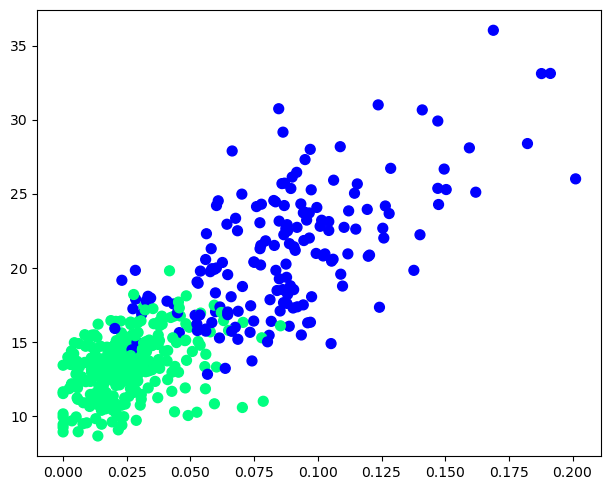

In [493]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(x_train[:,0],x_train[:,1],c=y_train,cmap='winter',s=50)

plt.tight_layout()
plt.show()

In [495]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.preprocessing import StandardScaler
import numpy as np

In [497]:
model = LogisticRegression()

In [499]:
model.fit(x_train,y_train)

LogisticRegression()

In [501]:
y_pred = model.predict(x_test)

In [503]:
print(model.intercept_)
print(model.coef_)

[17.48647267]
[[-0.89414328 -1.04687136]]


In [505]:
b = model.intercept_[0] # these values from Logistic Regression
w1 = model.coef_[0][0]
w2 = model.coef_[0][1]

In [507]:
 x1 = np.linspace(x_train[:,0].min(),x_train[:,0].max(),100)

In [513]:
x2 = -(b + w1*x1)/w2

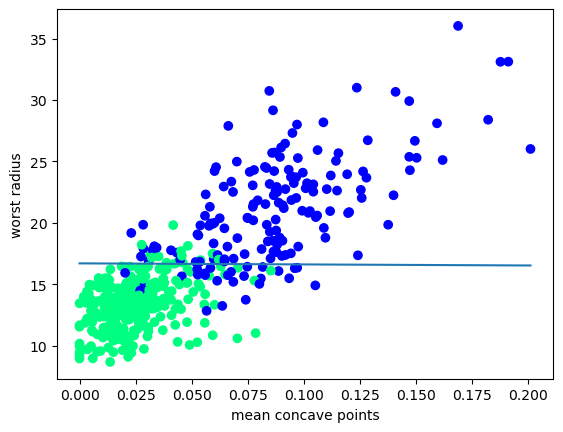

In [515]:
plt.scatter(
    x_train[:, 0],
    x_train[:, 1],
    c=y_train,
    cmap="winter"
)

plt.plot(x1, x2)

plt.xlabel(data.feature_names[7])
plt.ylabel(data.feature_names[20])
plt.show()

In [698]:
def step(z):
    return 1 if z>0 else 0

def perceptron(x,y):
    
    x = np.insert(x,0,1,axis=1)
    weights = np.ones(x.shape[1])
    lr = 0.01
    
    for i in range(10000):
        j = np.random.randint(0, x.shape[0])
        y_hat = step(np.dot(x[j],weights))
        weights = weights + lr*(y[j]-y_hat)*x[j]
    return weights[0],weights[1:]

        
        
       
 

In [700]:
intercept1_,coef1_ = perceptron(x_train,y_train)

In [748]:
print(coef1_)
print(intercept1_)



[ 0.20094709 -0.33292   ]
6.539999999999904


In [763]:
b = intercept1_ # these values from Logistic Regression
w1 = coef1_[0]
w2 = coef1_[1]

In [765]:
x1_prec = np.linspace(x_train[:, 0].min(), x_train[:, 0].max(), 100)
x2_prec = -(b + w1 * x1_prec) / w2

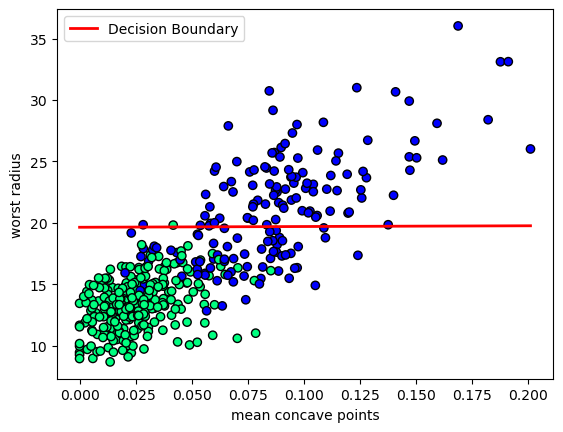

In [770]:
#Plot Perceptron decision boundary
plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train, cmap="winter", edgecolors='k')
plt.plot(x1_prec, x2_prec, color='red', linewidth=2, label='Decision Boundary')
plt.xlabel(data.feature_names[7])
plt.ylabel(data.feature_names[20])
plt.legend()
plt.show()